# Analisi di `transactions_simple_spatial_train.csv`

Dataset sintetico generato dall'esperimento **`simple_spatial`**: ogni cliente
appartiene a un cluster esplicito che ne definisce il livello di spesa
(`importo`), i merchant preferiti, i codici `cocau`. Le quattro classi (`famiglia_giorno`, `giovane_sera`,
`altospendente`, `mattiniero_utenze`) si distinguono quindi su variabili
*spaziali* (importo / merchant / cocau) più la frequenza temporale.

Obiettivi del notebook:
1. esplorare la distribuzione di ogni variabile (globale e per cluster);
2. costruire feature aggregate **per cliente** e proiettarle in 2D con
   **PCA** e **t-SNE**, colorando per cluster di verità.

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 60)

In [30]:
def find_repo_root(start: Path) -> Path:
    """Risale le cartelle finché trova la radice del repo (data/ + config.toml)."""
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "config.toml").exists():
            return p
    return start

ROOT = find_repo_root(Path.cwd())
CSV = ROOT / "data" / "transactions_simple_spatial_train.csv"

# Nomi colonna canonici (src/constant.py -> DataConfig)
CLIENT, CLUSTER, TS = "client_id", "cluster", "timestamp"
AMOUNT, MERCHANT, COCAU = "importo", "merchant", "cocau"

df = pd.read_csv(CSV)
df[TS] = pd.to_datetime(df[TS], unit="s")
print("File:", CSV)
print("Righe x colonne:", df.shape)
df.head()

File: /workspaces/be-bper-ai-toolchain-bseq-app/data/transactions_simple_spatial_train.csv
Righe x colonne: (481476, 6)


,client_id,cluster,timestamp,importo,merchant,cocau
0,0,cluster_2,2020-01-15 10:44:39,113.220763,PayPal,23
1,0,cluster_2,2020-02-01 07:47:44,39.743580,PayPal,66
2,0,cluster_2,2020-02-09 22:24:27,90.649953,PayPal,203
3,0,cluster_2,2020-02-11 00:14:52,68.761684,Vodafone,19
4,0,cluster_2,2020-02-28 05:00:42,51.221328,PayPal,23


## 0. Panoramica e qualità dei dati

## 1. Bilanciamento dei cluster

Numero di clienti e di transazioni per cluster (la verità di riferimento).

,n_clients,n_transactions,tx_per_client
cluster,,,
cluster_1,1000,119150,119.2
cluster_2,1000,118551,118.6
cluster_3,1000,124017,124.0
cluster_4,1000,119758,119.8


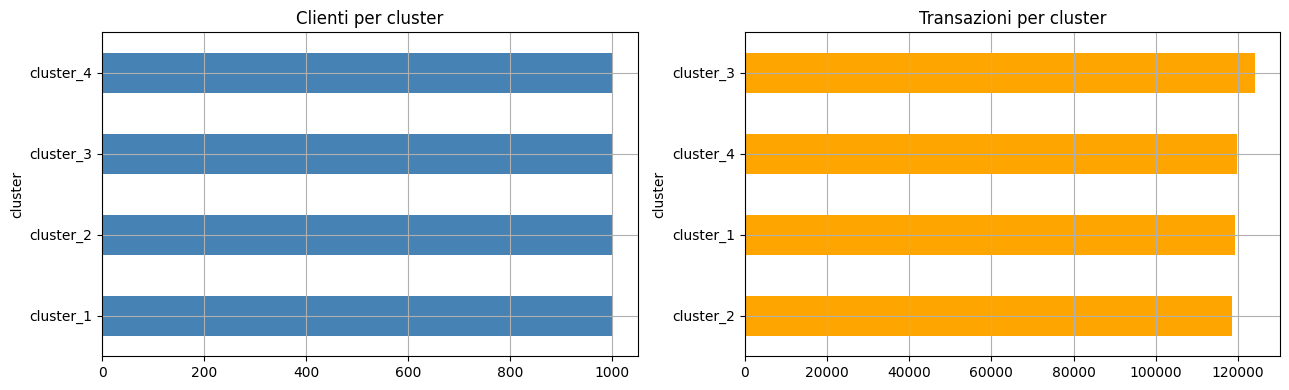

In [31]:
clusters = sorted(df[CLUSTER].unique())
n_clients = df.groupby(CLUSTER)[CLIENT].nunique()
n_tx = df[CLUSTER].value_counts()
summary = pd.DataFrame({"n_clients": n_clients, "n_transactions": n_tx})
summary["tx_per_client"] = (summary["n_transactions"] / summary["n_clients"]).round(1)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_clients.sort_values().plot.barh(ax=ax[0], color="steelblue", title="Clienti per cluster")
n_tx.sort_values().plot.barh(ax=ax[1], color="orange", title="Transazioni per cluster")
plt.tight_layout()

## 2. Distribuzione di `importo`

Il livello di spesa è uno dei discriminanti principali. `altospendente` è
generato come *solo debiti* (importi negativi), gli altri hanno il segno
che emerge dalle normali sottostanti.

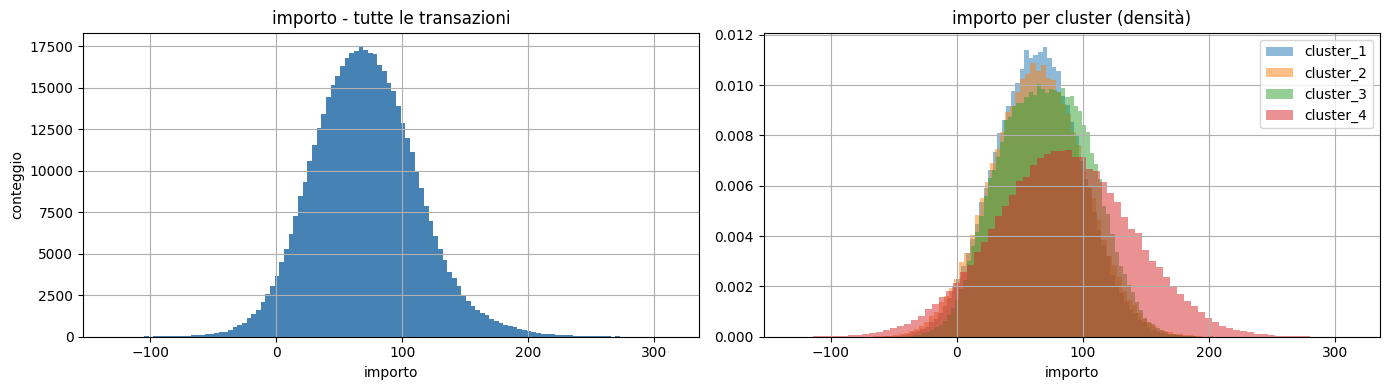

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df[AMOUNT], bins=120, color="steelblue")
ax[0].set(title="importo - tutte le transazioni", xlabel="importo", ylabel="conteggio")
for c in clusters:
    ax[1].hist(df.loc[df[CLUSTER] == c, AMOUNT], bins=80, alpha=0.5, density=True, label=c)
ax[1].set(title="importo per cluster (densità)", xlabel="importo")
ax[1].legend()
plt.tight_layout()

## 3. Variabili categoriche: `merchant` e `cocau`

I pool di merchant (e quindi i `cocau` associati) sono specifici per cluster:
è la parte *spaziale* del segnale.

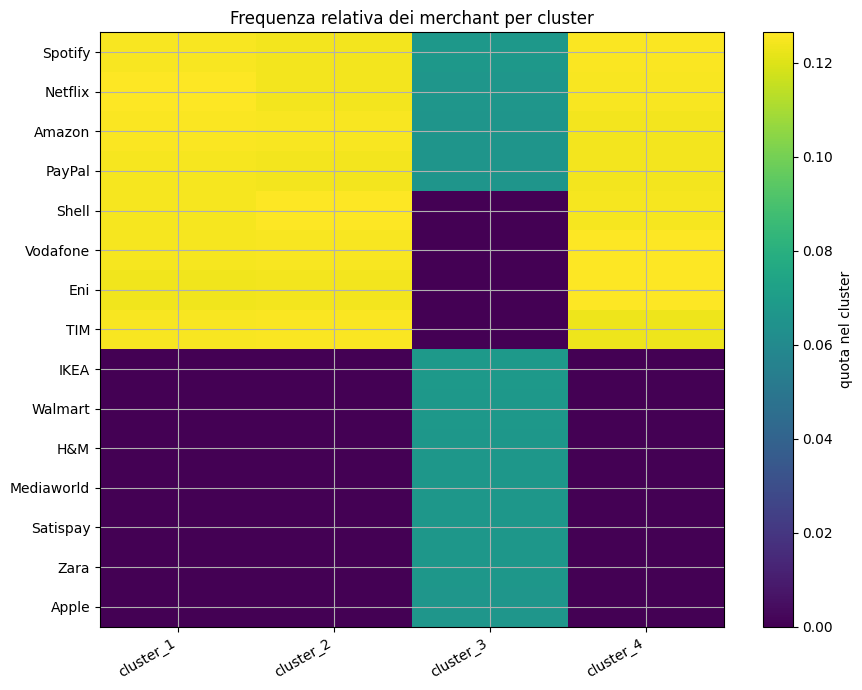

In [33]:
# Frequenza relativa dei merchant più comuni dentro ogni cluster
ct = pd.crosstab(df[MERCHANT], df[CLUSTER], normalize="columns")
top = df[MERCHANT].value_counts().head(15).index
ct = ct.loc[top]
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(ct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=30, ha="right")
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
ax.set_title("Frequenza relativa dei merchant per cluster")
fig.colorbar(im, ax=ax, label="quota nel cluster")
plt.tight_layout()

## 4. Variabili temporali

Per costruzione l'**ora del giorno** e il **giorno della settimana** sono
uniformi (non informativi): il segnale temporale vive solo nel **gap** tra
transazioni consecutive (`delta_t`), esponenziale con tasso `gap_lambda`
specifico per cluster.

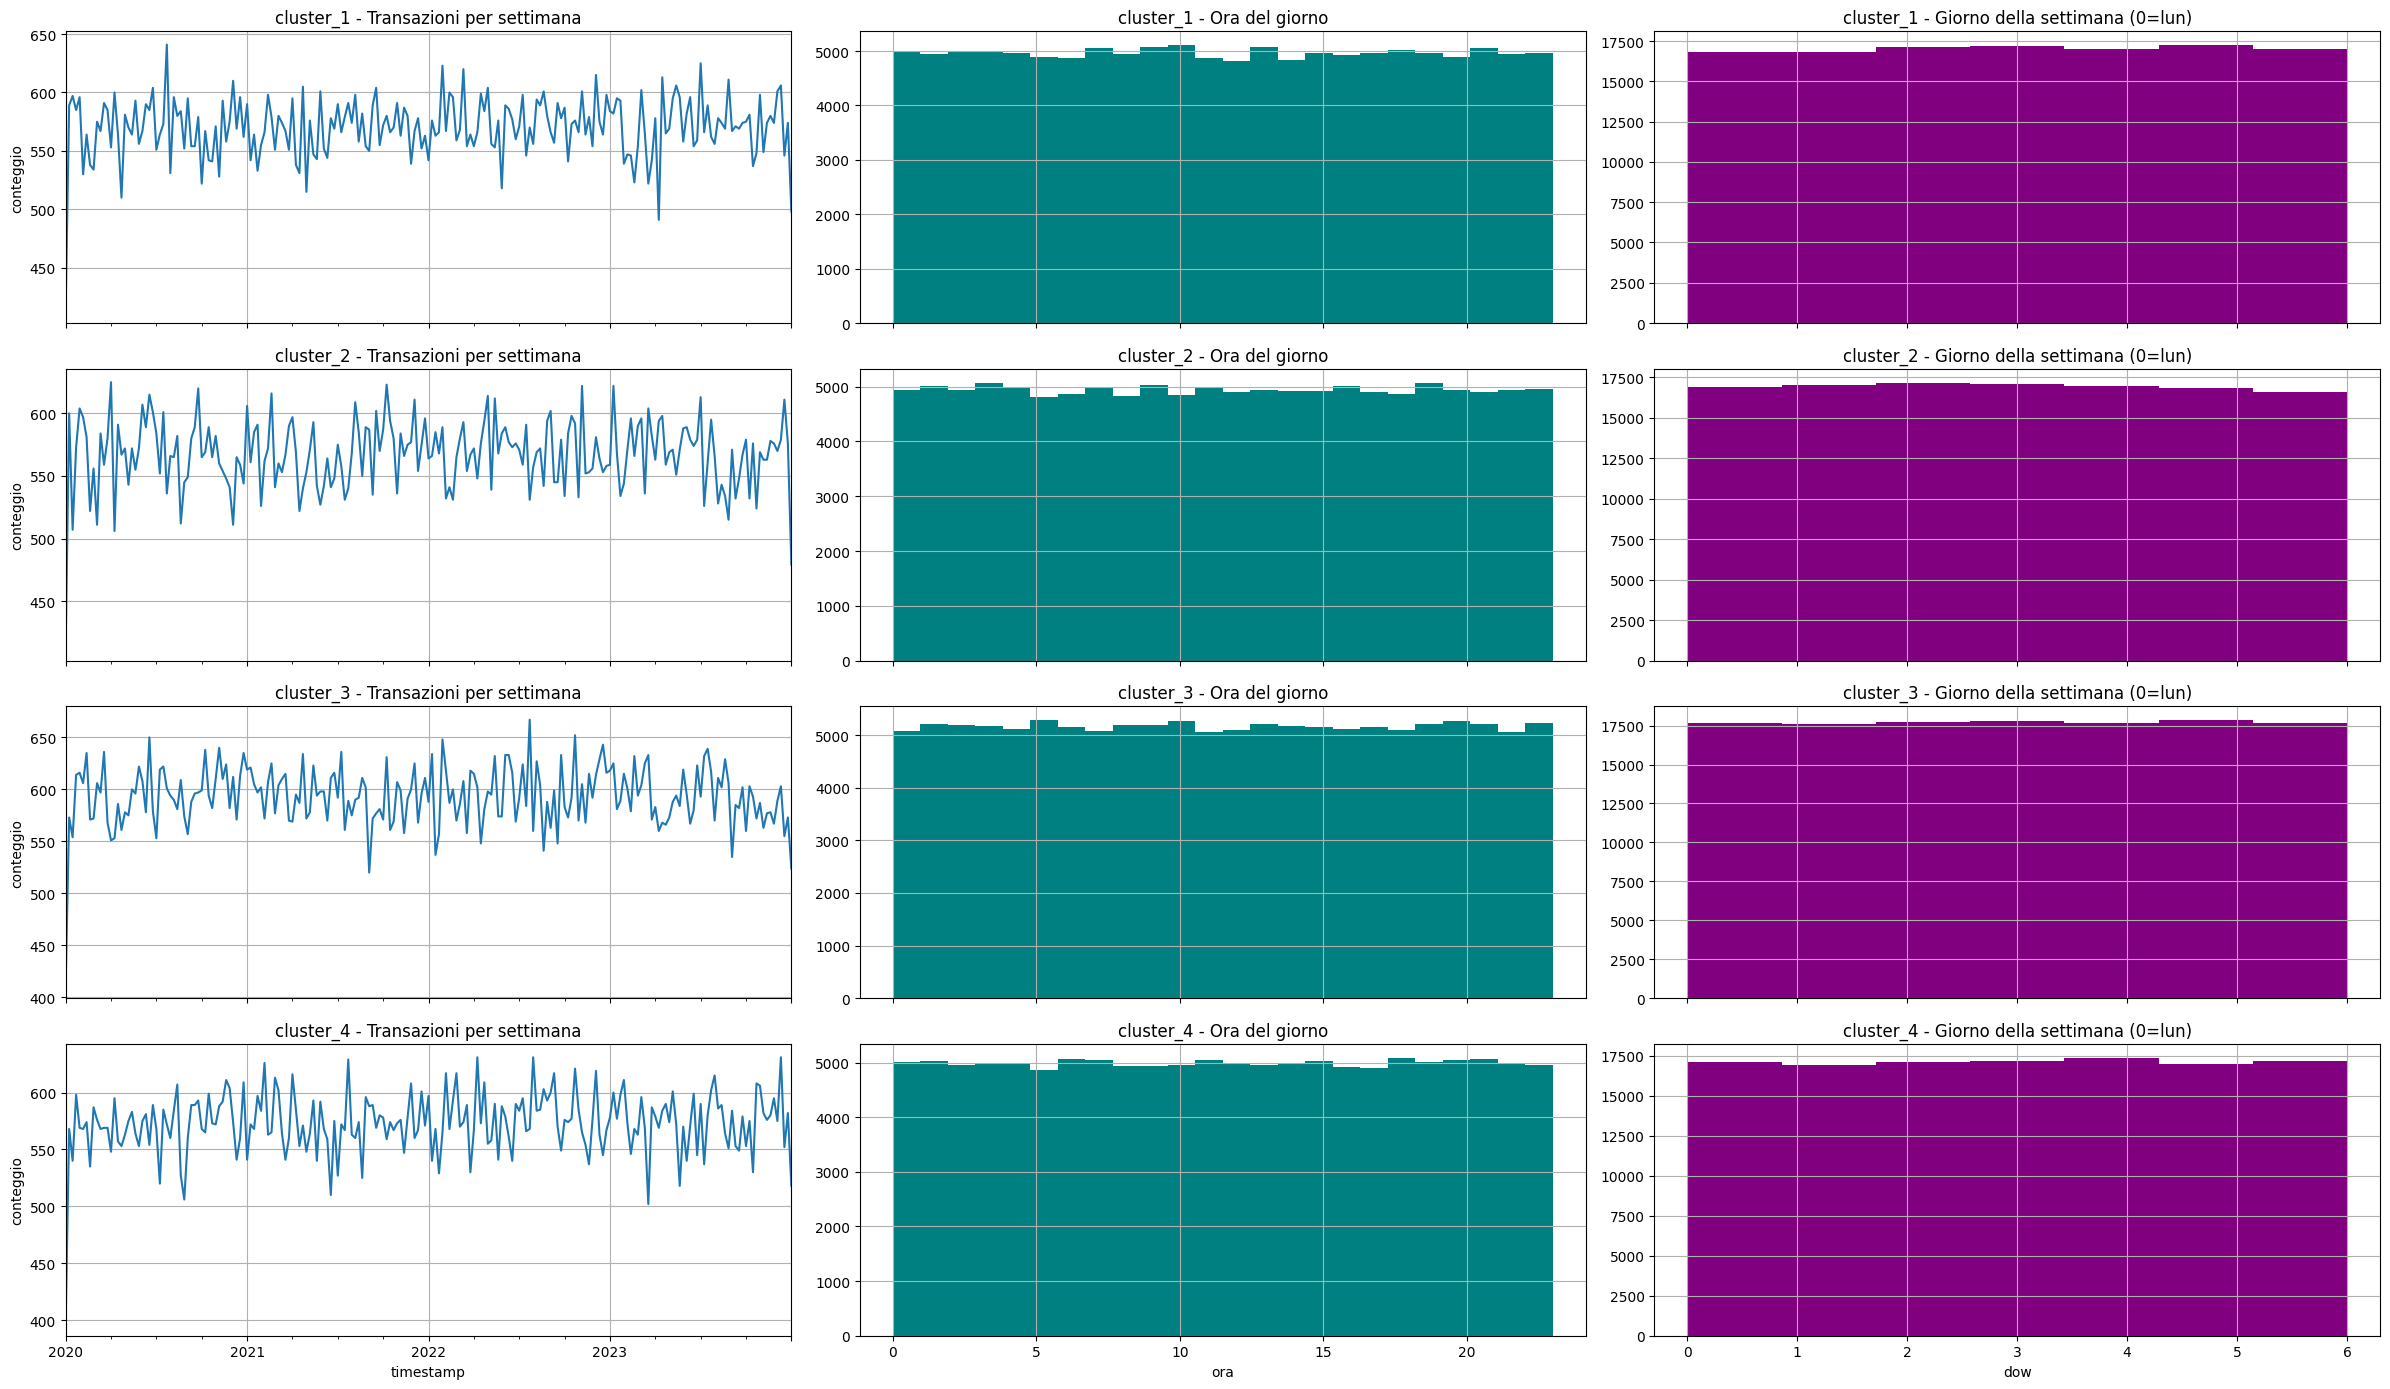

In [34]:
 fig, ax = plt.subplots(len(clusters), 3, figsize=(24, 3.5 * len(clusters)), sharex='col')
 
 for row, c in enumerate(clusters):
     df_c = df.loc[df[CLUSTER] == c].copy()
     weekly = df_c.set_index(TS).resample('W').size()
     weekly.plot(ax=ax[row, 0])
     ax[row, 0].set_title(f'{c} - Transazioni per settimana')
     ax[row, 0].set_ylabel('conteggio')
 
     ax[row, 1].hist(df_c[TS].dt.hour, bins=24, color='teal')
     ax[row, 1].set_title(f'{c} - Ora del giorno')
 
     ax[row, 2].hist(df_c[TS].dt.dayofweek, bins=7, color='purple')
     ax[row, 2].set_title(f'{c} - Giorno della settimana (0=lun)')
 
 for row in range(len(clusters)):
     ax[row, 1].set_xlabel('ora')
     ax[row, 2].set_xlabel('dow')
 
 plt.tight_layout()


In [35]:
df = df.sort_values(["client_id", "timestamp"])
df["delta_t_days"] = (
    df.groupby("client_id")["timestamp"]
      .diff()
      .dt.total_seconds()
      .div(86400)
)

,mean,median,std
cluster,,,
cluster_1,12.13,8.09,13.00
cluster_2,11.72,7.17,16.33
cluster_3,11.57,7.33,14.15
cluster_4,12.09,8.36,12.09


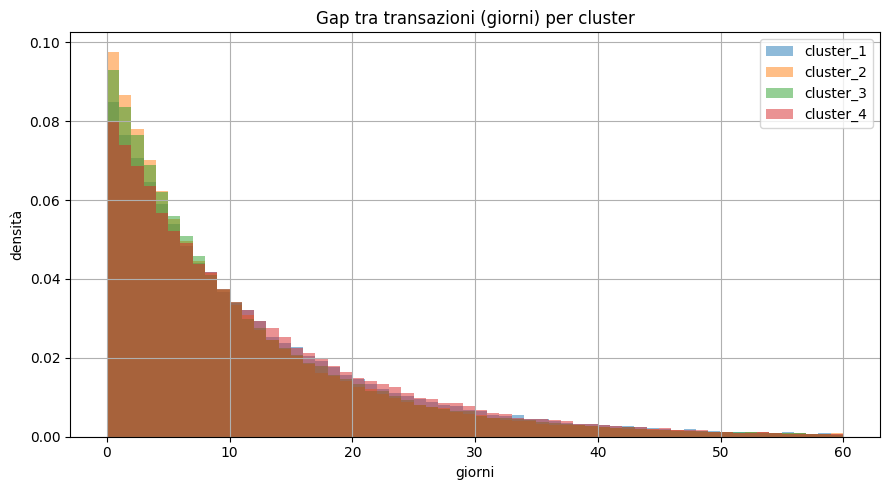

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
for c in clusters:
    gap = df.loc[df[CLUSTER] == c, "delta_t_days"].dropna()
    ax.hist(gap[gap < 60], bins=60, alpha=0.5, density=True, label=c)
ax.set(title="Gap tra transazioni (giorni) per cluster", xlabel="giorni", ylabel="densità")
ax.legend()
plt.tight_layout()

df.groupby(CLUSTER)["delta_t_days"].agg(["mean", "median", "std"]).round(2)

## 5. Transazioni per cliente

In [43]:
df

,client_id,cluster,timestamp,importo,merchant,cocau,delta_t_days
0,0,cluster_2,2020-01-15 10:44:39,113.220763,PayPal,23,NaN
1,0,cluster_2,2020-02-01 07:47:44,39.743580,PayPal,66,16.877141
2,0,cluster_2,2020-02-09 22:24:27,90.649953,PayPal,203,8.608831
3,0,cluster_2,2020-02-11 00:14:52,68.761684,Vodafone,19,1.076678
4,0,cluster_2,2020-02-28 05:00:42,51.221328,PayPal,23,17.198495
...,...,...,...,...,...,...,...
481471,3999,cluster_2,2023-07-31 19:15:36,101.983206,Eni,36,11.795231
481472,3999,cluster_2,2023-10-25 07:05:52,12.673514,Spotify,140,85.493241
481473,3999,cluster_2,2023-10-30 09:49:07,24.758748,Spotify,161,5.113368
481474,3999,cluster_2,2023-12-18 23:06:37,90.074054,TIM,260,49.553819


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
cluster_1,1000.0,119.15,30.29,17.0,98.75,119.0,140.0,220.0
cluster_2,1000.0,118.55,58.37,1.0,78.00,119.5,159.0,314.0
cluster_3,1000.0,124.02,47.28,1.0,93.00,123.0,158.0,266.0
cluster_4,1000.0,119.76,10.02,89.0,113.00,120.0,126.0,153.0


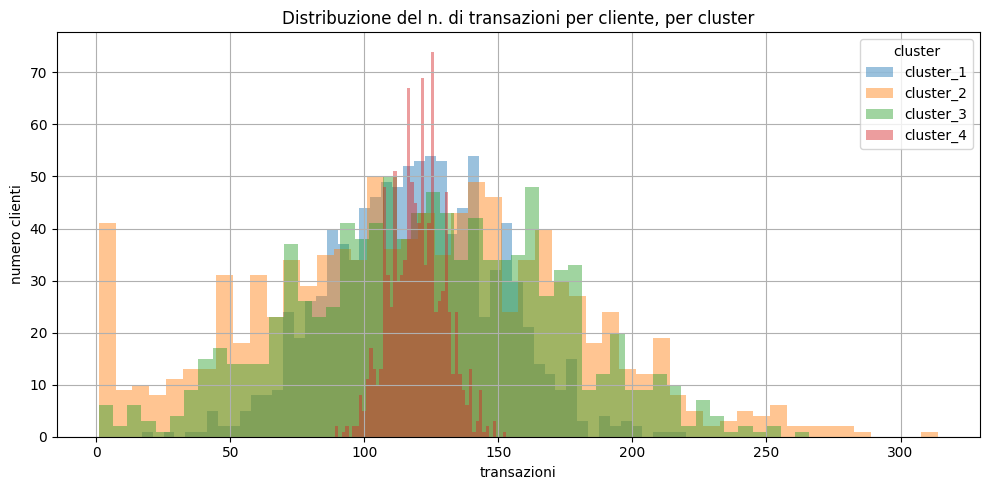

In [44]:
tx_per_client = (
    df.groupby([CLUSTER, CLIENT])
      .size()
      .rename("n_transazioni")
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for c in clusters:
    vals = tx_per_client.loc[tx_per_client[CLUSTER] == c, "n_transazioni"]
    ax.hist(vals, bins=50, alpha=0.45, label=c)

ax.set_title("Distribuzione del n. di transazioni per cliente, per cluster")
ax.set_xlabel("transazioni")
ax.set_ylabel("numero clienti")
ax.legend(title="cluster")
plt.tight_layout()

# Statistiche descrittive per cluster
(tx_per_client
 .groupby(CLUSTER)["n_transazioni"]
 .describe()
 .round(2))

## 6. Proiezione dei clienti (PCA & t-SNE)

I cluster sono definiti a livello di **cliente**, non di singola transazione.
Aggreghiamo quindi ogni cliente in un vettore di feature:

* statistiche su `importo` (media, std, mediana, |importo|, frazione di debiti);
* statistiche sul gap temporale (`gap_mean_days`, `gap_std_days`);
* numero di merchant / cocau distinti;
* istogramma normalizzato sui merchant e cocau più frequenti (top 15).

Dopo standardizzazione proiettiamo in 2D.

In [38]:
df

,client_id,cluster,timestamp,importo,merchant,cocau,delta_t_days
0,0,cluster_2,2020-01-15 10:44:39,113.220763,PayPal,23,NaN
1,0,cluster_2,2020-02-01 07:47:44,39.743580,PayPal,66,16.877141
2,0,cluster_2,2020-02-09 22:24:27,90.649953,PayPal,203,8.608831
3,0,cluster_2,2020-02-11 00:14:52,68.761684,Vodafone,19,1.076678
4,0,cluster_2,2020-02-28 05:00:42,51.221328,PayPal,23,17.198495
...,...,...,...,...,...,...,...
481471,3999,cluster_2,2023-07-31 19:15:36,101.983206,Eni,36,11.795231
481472,3999,cluster_2,2023-10-25 07:05:52,12.673514,Spotify,140,85.493241
481473,3999,cluster_2,2023-10-30 09:49:07,24.758748,Spotify,161,5.113368
481474,3999,cluster_2,2023-12-18 23:06:37,90.074054,TIM,260,49.553819


In [39]:
# feature aggregate per cliente
agg = df.groupby(CLIENT).agg(
    amount_mean=(AMOUNT, "mean"),
    amount_std=(AMOUNT, "std"),
    amount_median=(AMOUNT, "median"),
    amount_abs_mean=(AMOUNT, lambda s: np.mean(np.abs(s))),
    debt_frac=(AMOUNT, lambda s: np.mean(s < 0)),
    gap_mean_days=("delta_t_days", "mean"),
    gap_std_days=("delta_t_days", "std"),
    n_merchant=(MERCHANT, "nunique"),
    n_cocau=(COCAU, "nunique"),
)

labels = df.groupby(CLIENT)[CLUSTER].first()
feats = agg.fillna(0.0)

print(feats.shape, labels.shape)

(4000, 9) (4000,)


n_components PCA: 9
Varianza spiegata cumulata: [0.452 0.647 0.833 0.9   0.944 0.981 0.995 1.    1.   ]


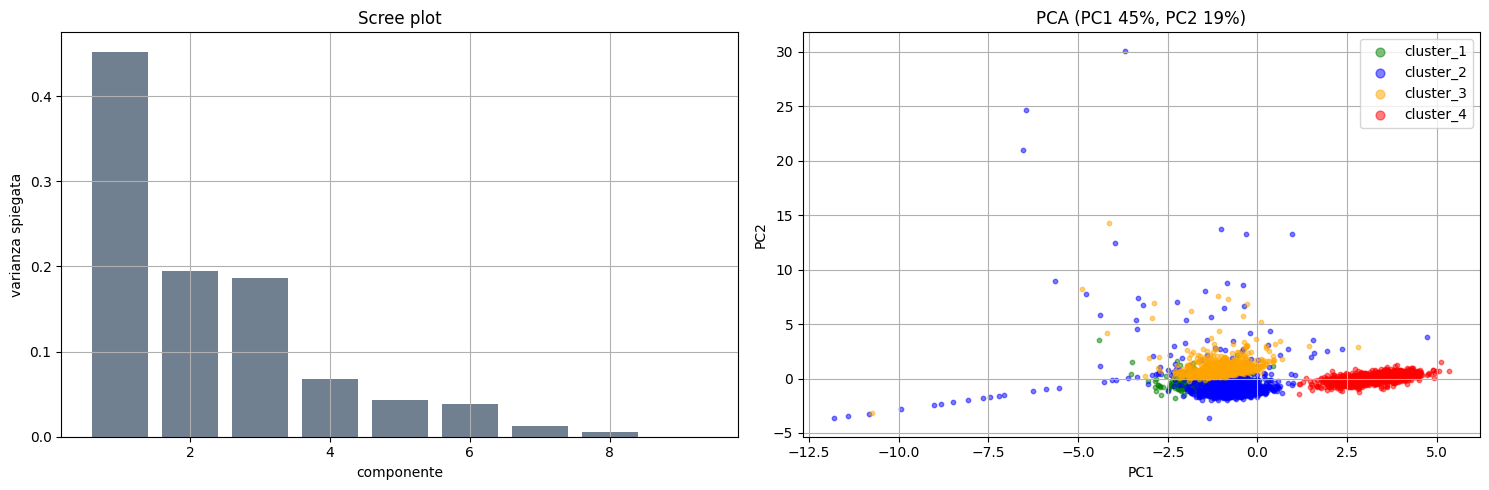

In [40]:
# Palette fissa per cluster
colors_map = {
    "cluster_3": "orange",
    "cluster_1": "green",
    "cluster_2": "blue",
    "cluster_4": "red",
}

X = StandardScaler().fit_transform(feats.values)
n_components = min(10, X.shape[0], X.shape[1])
pca = PCA(n_components=n_components, random_state=0).fit(X)
Xp = pca.transform(X)
evr = pca.explained_variance_ratio_
print("n_components PCA:", n_components)
print("Varianza spiegata cumulata:", np.round(np.cumsum(evr), 3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(1, len(evr) + 1), evr, color="slategray")
ax[0].set(title="Scree plot", xlabel="componente", ylabel="varianza spiegata")

for c in clusters:
    m = labels.values == c
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=10, alpha=0.5, label=c, color=colors_map.get(c, "gray"))

pc2_label = f"PC2 {evr[1]:.0%}" if len(evr) > 1 else "PC2 n/a"
ax[1].set(title=f"PCA (PC1 {evr[0]:.0%}, {pc2_label})", xlabel="PC1", ylabel="PC2")
ax[1].legend(markerscale=2)
plt.tight_layout()

In [41]:
# Feature che pesano di più sulle prime due componenti
load = pd.DataFrame(pca.components_[:2].T, index=feats.columns, columns=["PC1", "PC2"])
order = load["PC1"].abs().add(load["PC2"].abs()).sort_values(ascending=False).index
load.loc[order].head(12).round(3)

,PC1,PC2
n_cocau,0.316,-0.385
amount_median,0.437,0.217
amount_mean,0.447,0.206
amount_abs_mean,0.463,0.181
gap_std_days,-0.062,0.574
gap_mean_days,-0.066,0.561
debt_frac,0.270,-0.188
amount_std,0.451,-0.006
n_merchant,-0.105,0.225


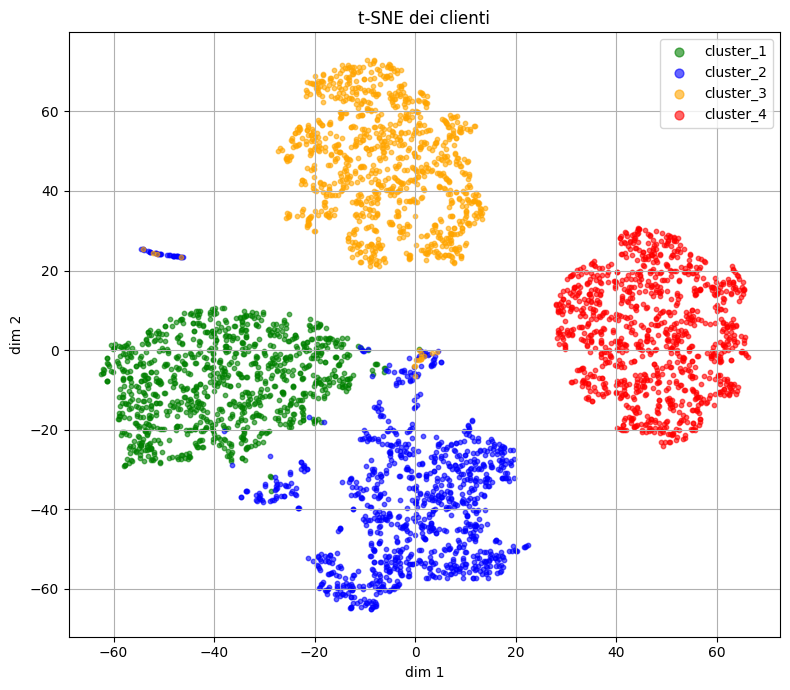

In [42]:
colors_map = {
    "cluster_3": "orange",
    "cluster_1": "green",
    "cluster_2": "blue",
    "cluster_4": "red",
}

tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0)
Xt = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 7))
for c in clusters:
    m = labels.values == c
    ax.scatter(Xt[m, 0], Xt[m, 1], s=10, alpha=0.6, label=c, color=colors_map.get(c, "gray"))
ax.set(title="t-SNE dei clienti", xlabel="dim 1", ylabel="dim 2")
ax.legend(markerscale=2)
plt.tight_layout()

## 7. Conclusioni

* I cluster differiscono nettamente per **livello di importo** e **segno**
  (`altospendente` = solo debiti, importi elevati), per i **pool di merchant /
  cocau** e per il **gap temporale** medio tra transazioni.
* Ora-del-giorno e giorno-della-settimana sono ~uniformi: nessun segnale,
  come atteso dal generatore.
* Sulle feature aggregate per cliente, PCA e t-SNE separano visibilmente le
  quattro classi: le prime due componenti catturano gran parte della varianza
  e i merchant/importi sono i loading dominanti.